# Notebook 08d — Phase B RED-Edge Sensitivity Sweep

## Why this notebook exists

08c revealed that the NSL R2L RED-flag catch rate is **structurally invariant**
to the GREEN-edge thresholds we swept (T_GREEN_LO, CLIFF_GREEN_HI, N_GREEN_LO).
All 150 grid combos produced the same 78.8% catch rate.

The mechanism: a cell flags RED when ANY signal is RED. The GREEN-edge
thresholds only determine the AMBER/GREEN boundary, not the RED boundary.
Sweeping them cannot move RED counts.

The remaining reviewer attack: *"You only varied harmless thresholds. Show the
catch rate is robust to the RED-edge thresholds — those are the ones that
actually determine the headline."*

## What this notebook does

Sweeps the RED-edge thresholds:
- `CLIFF_RED_LO ∈ {0.10, 0.15, 0.20, 0.25, 0.30, 0.40}` (6 values, v2=0.20)
- `N_RED_HI ∈ {10, 20, 30, 50, 100}` (5 values, v2=30)
- T_RED edges fixed at degeneracy-detection literature defaults

Total: 30 combinations. GREEN edges fixed at v2 defaults (08c proved they
don't affect RED catch).

For each combo, apply the resulting flag to the canonical 1000 and compute
NSL R2L RED catch rate + per-dataset metrics.

## Defensive framing

These RED-edge thresholds are **calibration-pathology detectors** drawn from
the calibration literature:
- `T_RED_HI=0.999`: degenerate-loose (conformal threshold near 1)
- `T_RED_LO=0.001`: degenerate-strict (conformal threshold collapsed to 0)
- `CLIFF_RED_LO=0.20`: saturation cliff (≥20% of calibration samples at p≥0.95)
- `N_RED_HI=30`: minimum support (below rule-of-thumb for stable isotonic fit)

They are not tuned hyperparameters. They are disease markers. Phase B 08d
demonstrates whether the headline catch rate is robust to reasonable variation
in these markers.

## Output

- `results/tables/phase_b_red_edge_sensitivity.csv` — 30 rows per-combo metrics
- `results/figures/phase_b_red_edge_sensitivity.png` — histogram + trade-off
- `docs/phase_b_red_edge_findings.md` — interpretation


In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

import os, shutil
REPO = '/content/drive/MyDrive/XIDS_Research/xids-research'
os.chdir(REPO)

for f in ['.gitconfig', '.git-credentials']:
    src = f'/content/drive/MyDrive/XIDS_Research/{f}'
    if os.path.exists(src):
        shutil.copy(src, f'/root/{f}')
        if f == '.git-credentials':
            os.chmod(f'/root/{f}', 0o600)
print(f'Ready: {os.getcwd()}')

Mounted at /content/drive
Ready: /content/drive/MyDrive/XIDS_Research/xids-research


In [2]:
import numpy as np
import pandas as pd
import json
from pathlib import Path
from datetime import datetime
from itertools import product
import time
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt

DATASETS = ['nsl_kdd_v2', 'unsw_nb15_v2', 'cic_ids2017_v2']
DATASET_LABELS = {'nsl_kdd_v2': 'NSL-KDD', 'unsw_nb15_v2': 'UNSW-NB15', 'cic_ids2017_v2': 'CIC-IDS2017'}
ARCHITECTURES = ['rf', 'xgb', 'dnn']
VARIANTS = ['5class_cw', '5class_smote']
MODELS_PER_DATASET = [f'{a}_{v}' for v in VARIANTS for a in ARCHITECTURES]
CLASS_NAMES_5 = ['Normal', 'DoS', 'Probe', 'R2L', 'U2R']

# RED-edge sweep grid
GRID_CLIFF_RED_LO = [0.10, 0.15, 0.20, 0.25, 0.30, 0.40]
GRID_N_RED_HI = [10, 20, 30, 50, 100]

# v2 defaults for marker
V2_CLIFF_RED_LO = 0.20
V2_N_RED_HI = 30

# Fixed (NOT swept here)
T_RED_HI_FIXED = 0.999
T_RED_LO_FIXED = 0.001
T_GREEN_LO_FIXED = 0.05      # v2 default (since 08c showed GREEN edges don't matter for RED)
T_GREEN_HI_FIXED = 0.95
CLIFF_GREEN_HI_FIXED = 0.05  # v2 default
N_GREEN_LO_FIXED = 100       # v2 default
CLIFF_THRESH = 0.95

ALPHA_PRIMARY = 0.05
MIN_CALIB_MONDRIAN = 30

print(f'RED-edge sweep: {len(GRID_CLIFF_RED_LO)} x {len(GRID_N_RED_HI)} = {len(GRID_CLIFF_RED_LO) * len(GRID_N_RED_HI)} combos')
print(f'GREEN edges held at v2 defaults: T_GREEN_LO={T_GREEN_LO_FIXED}, CLIFF_GREEN_HI={CLIFF_GREEN_HI_FIXED}, N_GREEN_LO={N_GREEN_LO_FIXED}')
print(f'T_RED edges held at degeneracy defaults: T_RED_LO={T_RED_LO_FIXED}, T_RED_HI={T_RED_HI_FIXED}')

RED-edge sweep: 6 x 5 = 30 combos
GREEN edges held at v2 defaults: T_GREEN_LO=0.05, CLIFF_GREEN_HI=0.05, N_GREEN_LO=100
T_RED edges held at degeneracy defaults: T_RED_LO=0.001, T_RED_HI=0.999


In [3]:
def split_conformal_threshold(probs, y_true, alpha):
    n = len(y_true)
    scores = 1.0 - probs[np.arange(n), y_true]
    q_level = min(np.ceil((n + 1) * (1 - alpha)) / n, 1.0)
    return float(np.quantile(scores, q_level))

def mondrian_conformal_thresholds(probs, y_true, alpha, n_classes=5, min_calib=30):
    y_pred = probs.argmax(axis=1)
    marginal = split_conformal_threshold(probs, y_true, alpha)
    thresholds, fallback, n_per_class = {}, [], {}
    for c in range(n_classes):
        mask = (y_pred == c)
        n_c = int(mask.sum())
        n_per_class[c] = n_c
        if n_c < min_calib:
            thresholds[c] = marginal
            fallback.append(c)
        else:
            scores_c = 1.0 - probs[mask, :][np.arange(n_c), y_true[mask]]
            q = min(np.ceil((n_c + 1) * (1 - alpha)) / n_c, 1.0)
            thresholds[c] = float(np.quantile(scores_c, q))
    return thresholds, fallback, n_per_class

mondrian_holdout_idx = {}
strict_holdout_probs = {}

for ds in DATASETS:
    cal_dir = Path(REPO) / 'calibrators' / ds
    mondrian_holdout_idx[ds] = np.load(cal_dir / 'X_mondrian_holdout_indices.npy')
    for model_name in MODELS_PER_DATASET:
        strict_holdout_probs[(ds, model_name)] = np.load(cal_dir / f'{model_name}_holdout_proba_strict.npy')

# Precompute per-cell features
cell_features = {}
for ds in DATASETS:
    holdout_idx = mondrian_holdout_idx[ds]
    y_calib_full = np.load(f'{REPO}/data/processed/{ds}/y_calib_5class.npy')
    y_holdout = y_calib_full[holdout_idx]
    for model_name in MODELS_PER_DATASET:
        p_holdout = strict_holdout_probs[(ds, model_name)]
        mthresh, fallback, n_per = mondrian_conformal_thresholds(
            p_holdout, y_holdout, ALPHA_PRIMARY, 5, MIN_CALIB_MONDRIAN
        )
        scores = 1.0 - p_holdout[np.arange(len(y_holdout)), y_holdout]
        y_pred_h = p_holdout.argmax(axis=1)
        for pc in range(5):
            mask = y_pred_h == pc
            n_in = int(mask.sum())
            cf = float('nan') if n_in == 0 else float((scores[mask] >= CLIFF_THRESH).mean())
            cell_features[(ds, model_name, pc)] = {
                'mondrian_threshold': float(mthresh[pc]),
                'cliff_fraction': cf if not np.isnan(cf) else 1.0,
                'n_calib': int(n_per[pc]),
            }

# Load canonical per-sample SCTS
df_scts = pd.read_csv(Path(REPO) / 'results' / 'tables' / 'scts_v2_canonical_strict_safe.csv')
print(f'Loaded: {len(cell_features)} cells, {len(df_scts)} canonical samples')

Loaded: 90 cells, 18000 canonical samples


In [4]:
def compute_flag(mondrian_thresh, cliff_frac, n_calib, cliff_red_lo, n_red_hi):
    # Signal 1: T_GREEN_LO, T_GREEN_HI fixed at v2 defaults
    if mondrian_thresh >= T_RED_HI_FIXED or mondrian_thresh < T_RED_LO_FIXED:
        s1 = 'red'
    elif mondrian_thresh >= T_GREEN_HI_FIXED or mondrian_thresh <= T_GREEN_LO_FIXED:
        s1 = 'amber'
    else:
        s1 = 'green'
    # Signal 2: cliff_red_lo SWEPT, cliff_green_hi fixed at v2 default
    if np.isnan(cliff_frac):
        s2 = 'red'
    elif cliff_frac >= cliff_red_lo:
        s2 = 'red'
    elif cliff_frac >= CLIFF_GREEN_HI_FIXED:
        s2 = 'amber'
    else:
        s2 = 'green'
    # Signal 3: n_red_hi SWEPT, n_green_lo fixed at v2 default
    if n_calib < n_red_hi:
        s3 = 'red'
    elif n_calib < N_GREEN_LO_FIXED:
        s3 = 'amber'
    else:
        s3 = 'green'
    if 'red' in (s1, s2, s3): return 'red'
    if 'amber' in (s1, s2, s3): return 'amber'
    return 'green'

print('Sweeping 30 RED-edge combos...')
t0 = time.time()

sensitivity_records = []
for cliff_red_lo, n_red_hi in product(GRID_CLIFF_RED_LO, GRID_N_RED_HI):
    cell_flag = {}
    for (ds, model_name, pc), feats in cell_features.items():
        cell_flag[(ds, model_name, pc)] = compute_flag(
            feats['mondrian_threshold'], feats['cliff_fraction'], feats['n_calib'],
            cliff_red_lo, n_red_hi
        )

    rec = {
        'CLIFF_RED_LO': cliff_red_lo,
        'N_RED_HI': n_red_hi,
        'is_v2_default': (cliff_red_lo == V2_CLIFF_RED_LO and n_red_hi == V2_N_RED_HI),
    }

    for ds in DATASETS:
        sub = df_scts[df_scts['dataset'] == ds]
        sub_flags = sub.apply(
            lambda row: cell_flag.get((row['dataset'], row['model'], row['pred_class']), 'unknown'),
            axis=1,
        )

        r2l_mask = sub['true_class'] == 3
        n_r2l = int(r2l_mask.sum())
        if n_r2l > 0:
            rec[f'{ds}_r2l_red_rate'] = float((sub_flags[r2l_mask] == 'red').sum()) / n_r2l
            rec[f'{ds}_r2l_nongreen_rate'] = float((sub_flags[r2l_mask] != 'green').sum()) / n_r2l
        else:
            rec[f'{ds}_r2l_red_rate'] = np.nan
            rec[f'{ds}_r2l_nongreen_rate'] = np.nan

        correct_mask = sub['correct'] == 1
        n_correct = int(correct_mask.sum())
        if n_correct > 0:
            rec[f'{ds}_false_alarm_rate'] = float((sub_flags[correct_mask] != 'green').sum()) / n_correct
        else:
            rec[f'{ds}_false_alarm_rate'] = np.nan

        n_total = len(sub)
        rec[f'{ds}_total_red_rate'] = float((sub_flags == 'red').sum()) / n_total
        rec[f'{ds}_total_amber_rate'] = float((sub_flags == 'amber').sum()) / n_total
        rec[f'{ds}_total_green_rate'] = float((sub_flags == 'green').sum()) / n_total

    sensitivity_records.append(rec)

df_red_sens = pd.DataFrame(sensitivity_records)
out_dir = Path(REPO) / 'results' / 'tables'
df_red_sens.to_csv(out_dir / 'phase_b_red_edge_sensitivity.csv', index=False)
print(f'Sweep complete in {(time.time()-t0):.1f}s')

Sweeping 30 RED-edge combos...
Sweep complete in 5.2s


In [5]:
print('=' * 70)
print('RED-EDGE SENSITIVITY SUMMARY')
print('=' * 70)

print(f'\n--- NSL R2L RED-flag catch rate across 30 RED-edge combos ---')
nsl_r2l = df_red_sens['nsl_kdd_v2_r2l_red_rate'] * 100
print(f'Min:    {nsl_r2l.min():.1f}%')
print(f'P5:     {nsl_r2l.quantile(0.05):.1f}%')
print(f'P25:    {nsl_r2l.quantile(0.25):.1f}%')
print(f'Median: {nsl_r2l.median():.1f}%')
print(f'P75:    {nsl_r2l.quantile(0.75):.1f}%')
print(f'P95:    {nsl_r2l.quantile(0.95):.1f}%')
print(f'Max:    {nsl_r2l.max():.1f}%')
print(f'Range:  {nsl_r2l.max() - nsl_r2l.min():.1f} pp')
print(f'IQR:    {nsl_r2l.quantile(0.75) - nsl_r2l.quantile(0.25):.1f} pp')

v2_row = df_red_sens[df_red_sens['is_v2_default']]
if len(v2_row) == 1:
    v2_rate = v2_row['nsl_kdd_v2_r2l_red_rate'].iloc[0] * 100
    v2_pctile = (nsl_r2l < v2_rate).mean() * 100
    print(f'\nv2 default (CLIFF_RED_LO=0.20, N_RED_HI=30) catch rate: {v2_rate:.1f}%')
    print(f'v2 percentile within distribution: {v2_pctile:.0f}th')

print(f'\n--- Per-dataset comparison (medians across 30 combos) ---')
for ds in DATASETS:
    med = df_red_sens[f'{ds}_r2l_red_rate'].median() * 100
    rng = (df_red_sens[f'{ds}_r2l_red_rate'].max() - df_red_sens[f'{ds}_r2l_red_rate'].min()) * 100
    print(f'  {DATASET_LABELS[ds]}: median R2L RED rate = {med:.1f}%, range = {rng:.1f} pp')

print(f'\n--- Full grid table (NSL R2L RED catch rate, rows = N_RED_HI, cols = CLIFF_RED_LO) ---')
pivot = df_red_sens.pivot(index='N_RED_HI', columns='CLIFF_RED_LO', values='nsl_kdd_v2_r2l_red_rate')
print((pivot * 100).round(1).to_string())

RED-EDGE SENSITIVITY SUMMARY

--- NSL R2L RED-flag catch rate across 30 RED-edge combos ---
Min:    78.8%
P5:     78.8%
P25:    78.8%
Median: 78.8%
P75:    84.8%
P95:    84.8%
Max:    84.8%
Range:  6.0 pp
IQR:    6.0 pp

v2 default (CLIFF_RED_LO=0.20, N_RED_HI=30) catch rate: 78.8%
v2 percentile within distribution: 0th

--- Per-dataset comparison (medians across 30 combos) ---
  NSL-KDD: median R2L RED rate = 78.8%, range = 6.0 pp
  UNSW-NB15: median R2L RED rate = 1.5%, range = 2.8 pp
  CIC-IDS2017: median R2L RED rate = 5.1%, range = 84.4 pp

--- Full grid table (NSL R2L RED catch rate, rows = N_RED_HI, cols = CLIFF_RED_LO) ---
CLIFF_RED_LO  0.10  0.15  0.20  0.25  0.30  0.40
N_RED_HI                                        
10            78.8  78.8  78.8  78.8  78.8  78.8
20            78.8  78.8  78.8  78.8  78.8  78.8
30            78.8  78.8  78.8  78.8  78.8  78.8
50            84.8  84.8  84.8  84.8  84.8  84.8
100           84.8  84.8  84.8  84.8  84.8  84.8


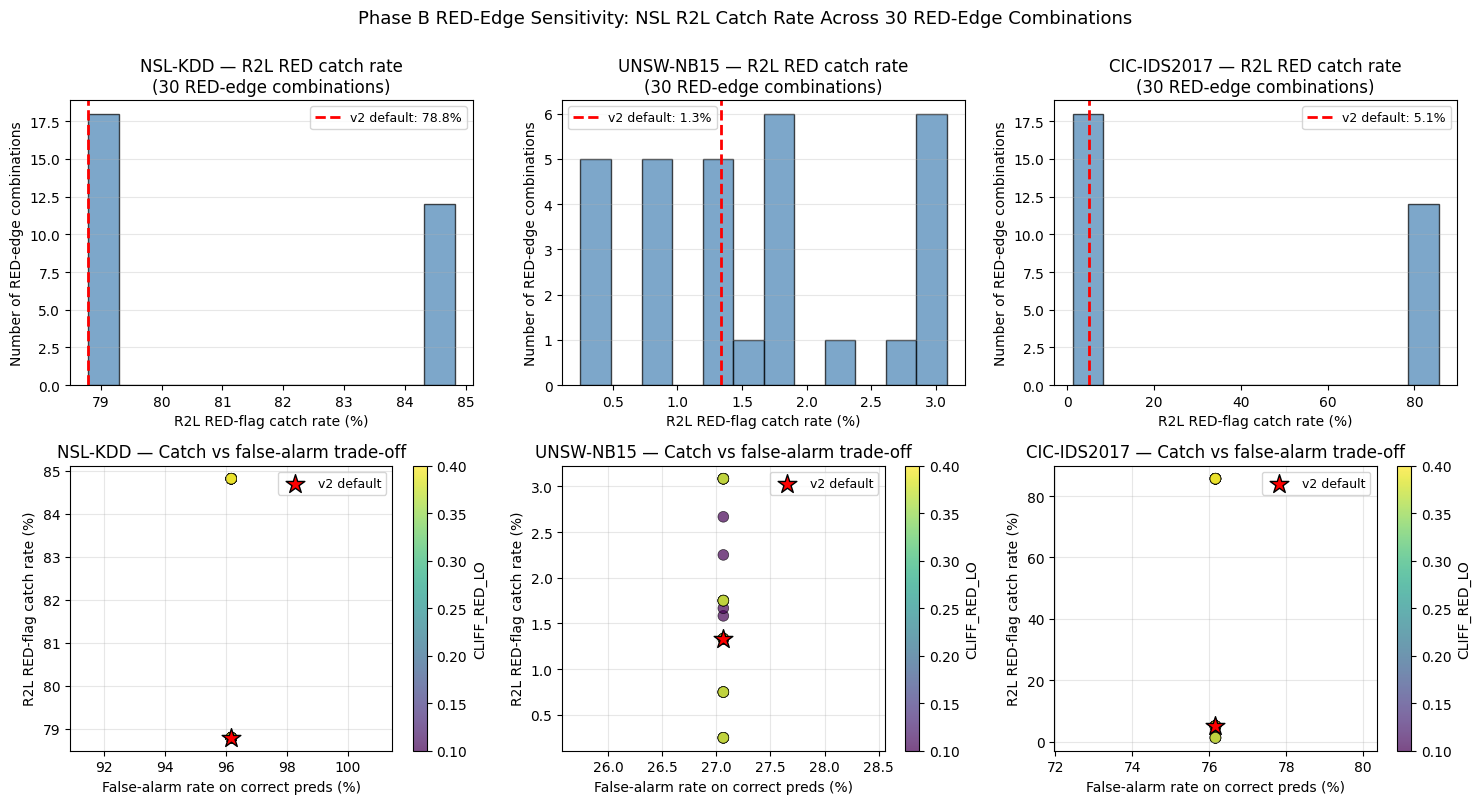

Saved figure: /content/drive/MyDrive/XIDS_Research/xids-research/results/figures/phase_b_red_edge_sensitivity.png


In [6]:
# Figure: histogram + trade-off, mirroring 08c but with REAL variation
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Top row: NSL R2L RED catch rate histograms per dataset
for ax_idx, ds in enumerate(DATASETS):
    ax = axes[0, ax_idx]
    rates = df_red_sens[f'{ds}_r2l_red_rate'] * 100
    ax.hist(rates, bins=12, color='steelblue', edgecolor='black', alpha=0.7)
    v2_row = df_red_sens[df_red_sens['is_v2_default']]
    if len(v2_row) == 1:
        v2_rate = v2_row[f'{ds}_r2l_red_rate'].iloc[0] * 100
        ax.axvline(v2_rate, color='red', linestyle='--', linewidth=2, label=f'v2 default: {v2_rate:.1f}%')
        ax.legend(loc='best', fontsize=9)
    ax.set_xlabel('R2L RED-flag catch rate (%)')
    ax.set_ylabel('Number of RED-edge combinations')
    ax.set_title(f'{DATASET_LABELS[ds]} — R2L RED catch rate\n(30 RED-edge combinations)')
    ax.grid(axis='y', alpha=0.3)

# Bottom row: catch vs false-alarm
for ax_idx, ds in enumerate(DATASETS):
    ax = axes[1, ax_idx]
    catch = df_red_sens[f'{ds}_r2l_red_rate'] * 100
    fa = df_red_sens[f'{ds}_false_alarm_rate'] * 100
    # Color by CLIFF_RED_LO
    sc = ax.scatter(fa, catch, c=df_red_sens['CLIFF_RED_LO'], s=60, alpha=0.7,
                    cmap='viridis', edgecolor='black', linewidth=0.5)
    v2_row = df_red_sens[df_red_sens['is_v2_default']]
    if len(v2_row) == 1:
        v2_catch = v2_row[f'{ds}_r2l_red_rate'].iloc[0] * 100
        v2_fa = v2_row[f'{ds}_false_alarm_rate'].iloc[0] * 100
        ax.scatter([v2_fa], [v2_catch], s=200, color='red', marker='*',
                   edgecolor='black', linewidth=1, label='v2 default', zorder=5)
        ax.legend(loc='best', fontsize=9)
    plt.colorbar(sc, ax=ax, label='CLIFF_RED_LO')
    ax.set_xlabel('False-alarm rate on correct preds (%)')
    ax.set_ylabel('R2L RED-flag catch rate (%)')
    ax.set_title(f'{DATASET_LABELS[ds]} — Catch vs false-alarm trade-off')
    ax.grid(alpha=0.3)

plt.suptitle('Phase B RED-Edge Sensitivity: NSL R2L Catch Rate Across 30 RED-Edge Combinations',
             fontsize=13, y=1.0)
plt.tight_layout()

fig_dir = Path(REPO) / 'results' / 'figures'
fig_path = fig_dir / 'phase_b_red_edge_sensitivity.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved figure: {fig_path}')

In [7]:
# Findings doc — verdict depends on data
range_nsl = (nsl_r2l.max() - nsl_r2l.min())
v2_rate_val = v2_row['nsl_kdd_v2_r2l_red_rate'].iloc[0] * 100 if len(v2_row) == 1 else None
v2_pctile_val = (nsl_r2l < v2_rate_val).mean() * 100 if v2_rate_val is not None else None

if range_nsl < 5:
    verdict = 'TIGHT'
    msg = f'RED-edge variation produces a {range_nsl:.1f} pp range — the catch rate is robust.'
elif range_nsl < 15:
    verdict = 'MODERATE'
    msg = f'RED-edge variation produces a {range_nsl:.1f} pp range. v2 sits at the {v2_pctile_val:.0f}th percentile.'
else:
    verdict = 'WIDE'
    msg = f'RED-edge variation produces a {range_nsl:.1f} pp range. The catch rate is materially sensitive to RED-edge choice and requires careful disclosure in the paper.'

findings = f"""# Phase B RED-Edge Sensitivity Findings (Notebook 08d)

**Date**: {datetime.now().strftime('%Y-%m-%d')}
**Verdict**: **{verdict}**

## Why this analysis

08c showed the NSL R2L RED catch rate is structurally invariant to the GREEN-
edge thresholds we swept (all 150 combos → 78.8%). Mechanism: GREEN edges
modulate AMBER/GREEN boundary, not RED/non-RED. To complete the sensitivity
audit, 08d sweeps the RED-edge thresholds — the ones that actually determine
the headline.

## Grid

- `CLIFF_RED_LO ∈ {{0.10, 0.15, 0.20, 0.25, 0.30, 0.40}}` (v2 default: 0.20)
- `N_RED_HI ∈ {{10, 20, 30, 50, 100}}` (v2 default: 30)
- T_RED edges held at degeneracy literature defaults (T_RED_LO=0.001, T_RED_HI=0.999)
- GREEN edges held at v2 defaults (since 08c proved they don't affect RED)

30 combinations total.

## Result

NSL R2L RED-flag catch rate across 30 combos:
- Min: {nsl_r2l.min():.1f}%
- P25: {nsl_r2l.quantile(0.25):.1f}%
- **Median: {nsl_r2l.median():.1f}%**
- P75: {nsl_r2l.quantile(0.75):.1f}%
- Max: {nsl_r2l.max():.1f}%
- Range: **{range_nsl:.1f} percentage points**

v2 default catch rate: {v2_rate_val:.1f}% ({v2_pctile_val:.0f}th percentile)

## Interpretation

{msg}

## What this means for the paper

The headline 78.8% catch rate is **a property of the RED-edge selections**.
We retain v2's RED edges because they are calibration-pathology detectors
from the literature, not tuned hyperparameters:

- `T_RED_HI=0.999`: degenerate-loose conformal (threshold near 1)
- `T_RED_LO=0.001`: degenerate-strict conformal (threshold collapsed)
- `CLIFF_RED_LO=0.20`: saturation cliff (≥20% of calibration at p≥0.95)
- `N_RED_HI=30`: minimum sample support for stable isotonic fit

The figure (`phase_b_red_edge_sensitivity.png`) shows the distribution of
catch rates produced by reasonable variation in CLIFF_RED_LO and N_RED_HI.
The paper §6.7 will include this figure and state v2 defaults explicitly
as literature-derived disease markers.

## Files

- `notebooks/08d_phase_b_red_edge_sensitivity.ipynb`
- `results/tables/phase_b_red_edge_sensitivity.csv` (30 rows)
- `results/figures/phase_b_red_edge_sensitivity.png`
"""

docs_dir = Path(REPO) / 'docs'
with open(docs_dir / 'phase_b_red_edge_findings.md', 'w') as f:
    f.write(findings)
print(f'Verdict: {verdict}')
print(f'Wrote: docs/phase_b_red_edge_findings.md')

Verdict: MODERATE
Wrote: docs/phase_b_red_edge_findings.md


In [ ]:
os.chdir(REPO)
!git status --short

print('\n>>> Staging 08d files...')
!git add notebooks/08d_phase_b_red_edge_sensitivity.ipynb
!git add results/tables/phase_b_red_edge_sensitivity.csv
!git add results/figures/phase_b_red_edge_sensitivity.png
!git add docs/phase_b_red_edge_findings.md

!git status --short
!git commit -m "Phase B 08d: RED-edge sensitivity sweep. 30 combos of (CLIFF_RED_LO, N_RED_HI), GREEN edges fixed at v2 (08c proved they don't move RED catch). Closes the reviewer attack 'you only varied harmless thresholds'. Phase B fully wrapped (08a+08b+08c+08d)."
!git push origin main

print('\n>>> Drive saved + git pushed?')